### 利用したデータセット
kaggleに公開してあるデータセットを利用

Online Shoppers Purchasing Intention Dataset  
https://www.kaggle.com/datasets/imakash3011/online-shoppers-purchasing-intention-dataset/data

In [1]:
# %% [markdown]
# # Online Shoppers（購入フラグの二値分類）
# - 目的: `購入フラグ`（Yes/No）を MLP（Keras）で予測
# - ポイント: 前処理は ColumnTransformer、評価は AUC/PR-AUC を重視
# - 再現性: RANDOM_STATE を None（非再現）または整数（再現）に切替可能

# %%
# --- 処理1.セットアップ＆乱数制御
import os, random
from typing import Optional

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# --- ユーザー設定: 再現性スイッチ（None なら非再現、整数なら固定） ---
RANDOM_STATE: Optional[int] = 42  # 例: None, 42, 2025 など

def seed_everything(seed: Optional[int] = None) -> None:
    """NumPy/標準random/TensorFlowの乱数を制御。None の場合は非決定（そのまま）。"""
    if seed is None:
        print("乱数シード: None（非再現ラン）")
        return
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"乱数シード: {seed}")

seed_everything(RANDOM_STATE)
pd.options.display.max_columns = None


乱数シード: 42


In [2]:
# %%
# --- 処理2.データ読込（Kaggle から取得した CSV はLesson13フォルダ直下に設置）
CSV_PATH = "online_shoppers_intention.csv"  # 同じフォルダの直下に設置
df = pd.read_csv(CSV_PATH)
print("原データ shape:", df.shape)
display(df.head())

原データ shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# %%
# --- 処理3.日本語カラム名への一括リネーム
# Kaggle配布の英語カラム → わかりやすい日本語名へ変換
rename_map = {
    "Revenue": "購入フラグ",                        # 目的変数（True/False）
    "Administrative": "管理ページ数",
    "Administrative_Duration": "管理ページ滞在秒",
    "Informational": "情報ページ数",
    "Informational_Duration": "情報ページ滞在秒",
    "ProductRelated": "商品関連ページ数",
    "ProductRelated_Duration": "商品関連ページ滞在秒",
    "BounceRates": "直帰率",
    "ExitRates": "離脱率",
    "PageValues": "ページ価値",
    "SpecialDay": "特別日近接度",
    "Month": "月",
    "OperatingSystems": "OS",
    "Browser": "ブラウザ",
    "Region": "地域",
    "TrafficType": "流入タイプ",
    "VisitorType": "訪問者種別",
    "Weekend": "週末",
}

# 存在する列のみリネーム（将来の互換性のため）
rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
df_ja = df.rename(columns=rename_map).copy()

print("日本語化後 shape:", df_ja.shape)
display(df_ja.head())


日本語化後 shape: (12330, 18)


,管理ページ数,管理ページ滞在秒,情報ページ数,情報ページ滞在秒,商品関連ページ数,商品関連ページ滞在秒,直帰率,離脱率,ページ価値,特別日近接度,月,OS,ブラウザ,地域,流入タイプ,訪問者種別,週末,購入フラグ
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# %%
# --- 処理4.目的変数/特徴量の指定
# 目的変数: True/False → 0/1 に変換して学習可能な形式に
TARGET = "購入フラグ"
assert TARGET in df_ja.columns, f"{TARGET} が見つかりません。CSV列名を確認してください。"
y = df_ja[TARGET].astype(int).values  # bool→int（0/1）

# 特徴量（数値・カテゴリを明示）※存在チェック込み
NUM_COLS_JA = [
    "管理ページ数","管理ページ滞在秒",
    "情報ページ数","情報ページ滞在秒",
    "商品関連ページ数","商品関連ページ滞在秒",
    "直帰率","離脱率","ページ価値","特別日近接度"
]
CAT_COLS_JA = [
    "月","OS","ブラウザ","地域","流入タイプ","訪問者種別","週末"
]

NUM_COLS_JA = [c for c in NUM_COLS_JA if c in df_ja.columns]
CAT_COLS_JA = [c for c in CAT_COLS_JA if c in df_ja.columns]

X = df_ja[NUM_COLS_JA + CAT_COLS_JA].copy()

print(f"陽性率（購入フラグ=1）: {y.mean():.3f}")
print("数値列:", NUM_COLS_JA)
print("カテゴリ列:", CAT_COLS_JA)
print("特徴量数:", X.shape[1])


陽性率（購入フラグ=1）: 0.155
数値列: ['管理ページ数', '管理ページ滞在秒', '情報ページ数', '情報ページ滞在秒', '商品関連ページ数', '商品関連ページ滞在秒', '直帰率', '離脱率', 'ページ価値', '特別日近接度']
カテゴリ列: ['月', 'OS', 'ブラウザ', '地域', '流入タイプ', '訪問者種別', '週末']
特徴量数: 17


In [5]:
# %%
# --- 処理5.学習/評価データに分割
# stratify=y: クラス比を維持して分割（不均衡対策の基本）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "test:", X_test.shape)

train: (9864, 17) test: (2466, 17)


In [9]:
# 訓練データを確認
print("-" * 30,"y_train","-" * 30)
display(y_train)
print("-" * 30,"X_train","-" * 30)
display(X_train)

------------------------------ y_train ------------------------------


array([0, 0, 0, ..., 0, 0, 1])

------------------------------ X_train ------------------------------


,管理ページ数,管理ページ滞在秒,情報ページ数,情報ページ滞在秒,商品関連ページ数,商品関連ページ滞在秒,直帰率,離脱率,ページ価値,特別日近接度,月,OS,ブラウザ,地域,流入タイプ,訪問者種別,週末
4263,8,732.250000,0,0.0,34,1345.755952,0.005128,0.013342,12.274195,0.8,May,3,3,3,2,Returning_Visitor,False
5905,0,0.000000,0,0.0,4,157.200000,0.040000,0.100000,0.000000,0.0,Oct,1,8,3,1,Returning_Visitor,True
9434,0,0.000000,0,0.0,4,42.000000,0.000000,0.050000,0.000000,0.0,Dec,2,10,1,2,Returning_Visitor,False
3505,2,338.000000,0,0.0,17,1205.566667,0.012500,0.037500,19.236250,0.8,May,3,2,2,2,Returning_Visitor,False
2067,0,0.000000,0,0.0,32,827.646212,0.000000,0.000587,54.676348,0.0,Mar,2,2,7,2,Returning_Visitor,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2419,4,69.000000,1,0.0,19,580.500000,0.010526,0.049123,22.329347,0.0,May,2,2,1,3,Returning_Visitor,True
1200,4,16.666667,0,0.0,68,2593.741667,0.002941,0.012843,0.000000,0.0,Mar,2,2,4,8,Returning_Visitor,False
2398,0,0.000000,0,0.0,17,433.133333,0.023529,0.051961,0.000000,1.0,May,3,2,4,4,Returning_Visitor,True
11106,0,0.000000,0,0.0,73,2784.800000,0.002740,0.015318,6.135982,0.0,Nov,2,2,5,2,Returning_Visitor,True


In [ ]:
# %%
# --- 処理6.前処理パイプライン（学習データのみ fit → 情報漏洩を防止）
# 数値は標準化（平均0,分散1）、カテゴリはOne-Hot化（未知カテゴリは無視）

import sklearn
from packaging import version
from sklearn.preprocessing import OneHotEncoder

print("scikit-learn version:", sklearn.__version__)

ohe_kwargs = dict(handle_unknown="ignore")
# OneHotEncoder の "sparse" → "sparse_output" 互換対応
# - scikit-learn 1.2 以上:    sparse_output=False
# - scikit-learn 1.2 未満:    sparse=False
# どちらも「密行列（dense）」を出す設定。Keras MLP に渡しやすい。
if version.parse(sklearn.__version__) >= version.parse("1.2"):
    ohe_kwargs["sparse_output"] = False   # 新パラメータ（1.2+）
else:
    ohe_kwargs["sparse"] = False          # 旧パラメータ（<1.2）

categorical_tf = OneHotEncoder(**ohe_kwargs)

# 数値はこれまで通り標準化
from sklearn.preprocessing import StandardScaler
numeric_tf = StandardScaler()

from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, NUM_COLS_JA),
        ("cat", categorical_tf, CAT_COLS_JA),
    ]
)

# fit は train のみ（情報漏洩を防止）
Xt_train = preprocessor.fit_transform(X_train)
Xt_test  = preprocessor.transform(X_test)

print("前処理後の入力次元:", Xt_train.shape[1], "(dense)")


scikit-learn version: 1.6.1
前処理後の入力次元: 75 (dense)


In [ ]:
# %%
# --- 処理7: クラス不均衡への重み付け
# データの偏りに応じて class_weight を計算（バランス自動計算）。
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("class_weight:", class_weight)

class_weight: {0: 0.5915087550971456, 1: 3.2319790301441675}


In [18]:
# %%
# --- 処理8.MLP モデル定義（出力=Sigmoid、損失=Binary Crossentropy）
# input_dim を前処理結果 Xt_train から取得
input_dim = Xt_train.shape[1]
print("モデル入力次元（input_dim）:", input_dim)

def build_mlp(input_dim: int, hidden_units=(64, 32), dropout=0.2, lr=1e-3) -> keras.Model:
    """
    Tabular（二値分類）向けの小型MLP。BatchNorm/Dropoutで過学習を抑制。
    - Dense層: ReLU
    - 正則化: BatchNormalization + Dropout
    - 出力層: 1ユニット + Sigmoid（確率出力 0..1）
    """
    inputs = keras.Input(shape=(input_dim,))
    x = keras.layers.Dense(hidden_units[0], activation="relu")(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Dense(hidden_units[1], activation="relu")(x)
    x = keras.layers.Dropout(dropout)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)  # 二値: 確率[0,1]

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",                       # 二値分類の定石
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]  # AUCも併記
    )
    return model

model = build_mlp(input_dim)
model.summary()


モデル入力次元（input_dim）: 75


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,233 (28.25 KB)

 Trainable params: 7,105 (27.75 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# %%
# --- 処理9.学習（class_weight の適用を明示）
# 検証指標（AUC）を監視し、改善が止まったら自動停止します。
# --- 早期停止で過学習を回避 ---
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=20, restore_best_weights=True
    )
]

# --- class_weight の使い分け ---
# ・「クラス不均衡が強い」と判断した時のみ True にする（目安: 陽性率 < 0.3 など）
USE_CLASS_WEIGHT = True

# 処理7で作った class_weight を fit() に渡す。
# まだ class_weight が無ければ None にフォールバック（学習は継続可能）
class_weight_param = None
if USE_CLASS_WEIGHT and "class_weight" in globals():
    class_weight_param = class_weight  # 例: {0: 0.7, 1: 1.3} など

history = model.fit(
    Xt_train, y_train,
    validation_split=0.2,      # テストは最後まで未使用（リーク防止）
    epochs=300, batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight_param  # ★ここで重み付けを適用
)

Epoch 1/300
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7163 - auc: 0.8159 - loss: 0.5346 - val_accuracy: 0.8363 - val_auc: 0.8771 - val_loss: 0.4481
Epoch 2/300
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.8104 - auc: 0.8837 - loss: 0.4349 - val_accuracy: 0.8226 - val_auc: 0.8898 - val_loss: 0.3995
Epoch 3/300
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.8309 - auc: 0.9058 - loss: 0.3931 - val_accuracy: 0.8211 - val_auc: 0.8976 - val_loss: 0.3893
Epoch 4/300
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.8306 - auc: 0.9108 - loss: 0.3814 - val_accuracy: 0.8231 - val_auc: 0.9028 - val_loss: 0.3778
Epoch 5/300
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.8323 - auc: 0.9165 - loss: 0.3660 - val_accuracy: 0.8089 - val_auc: 0.9068 - val_loss: 0.3965
Epoch 6/300
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 0.8364 - auc: 0.9222 - loss: 0.3533 - val_accuracy: 0.8262 - val_auc: 0.9077 - val_loss: 0.3766
Epoch 7/300
124/124 ━━━━

In [ ]:
# %%
# --- 処理10.評価（AUC/PR-AUC/混同行列/レポート）
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

eval_res = model.evaluate(Xt_test, y_test, verbose=0)
print("評価指標:", dict(zip(model.metrics_names, eval_res)))

# 予測確率（0..1）
y_prob = model.predict(Xt_test, verbose=0).ravel()

# しきい値0.5でクラス化（必要に応じて調整）
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


評価指標: {'loss': 0.3774760961532593, 'compile_metrics': 0.9140471816062927}
              precision    recall  f1-score   support

           0     0.9694    0.8201    0.8885      2084
           1     0.4666    0.8586    0.6046       382

    accuracy                         0.8260      2466
   macro avg     0.7180    0.8393    0.7465      2466
weighted avg     0.8915    0.8260    0.8445      2466

ROC-AUC: 0.9143712755373778
PR-AUC (Average Precision): 0.6773992952400206
Confusion matrix:
 [[1709  375]
 [  54  328]]


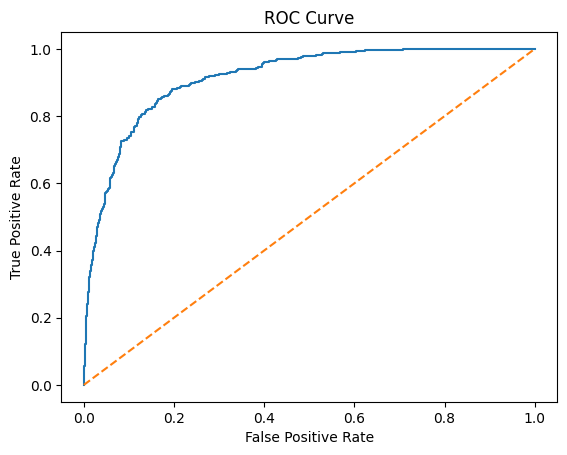

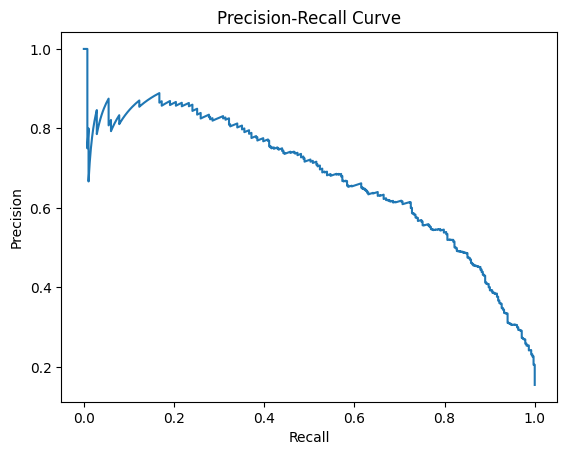

In [ ]:
# %%
# --- 処理11.ROC / Precision-Recall 曲線可視化
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# ROC曲線
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
# ROCの軸は「横＝FPR、縦＝TPR(=Recall)」。
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate") # 偽陽性率（FPR）＝買ってないのに「買う」と言っちゃう割合
plt.ylabel("True Positive Rate") # 真陽性率（TPR＝再現率）＝本当は買った人をちゃんと「買う」と言える割合
plt.title("ROC Curve") # ROC曲線
plt.show()

# PR曲線（不均衡データに有用）
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure()
# PRの軸は「横＝Recall、縦＝Precision」。
plt.plot(recall, precision)
plt.xlabel("Recall") # 再現率（見逃さない力）
plt.ylabel("Precision") # 適合率（当てた“買う”のうち、本当に買った割合＝無駄撃ちの少なさ）
plt.title("Precision-Recall Curve") # 適合率・再現率曲線
plt.show()